# Elevation Analysis - GMTED2010 Dataset

## Analysis Structure

**Section 0: Setup & Imports**
- Configure multi-threading
- Import required libraries
- Define helper functions

**Section 1: Initial Data Loading**
- Load ESRI Grid raster (elevation data)
- Display dataset summary
- Quick initial assessment

**Section 2: Spatial Operations**
- Load fire point locations
- Create bounding box with buffer
- Clip raster to fire locations
- Extract elevation values at fire coordinates
- Visualize clipped raster with fire overlay

**Section 3: Data Preprocessing**
- Handle NoData values and sentinels
- Compute derived features (slope, aspect, terrain roughness)
- Normalize elevation features
- Validate preprocessing results

**Section 4: Exploratory Data Analysis**
- Descriptive statistics
- Elevation distribution analysis
- Terrain characteristics analysis
- Fire vs elevation relationship

**Section 5: Save Results**
- Save elevation features with fire data
- Save clipped raster
- Generate summary report

---
## Section 0: Setup & Imports

In [1]:
import os
import multiprocessing

def configure_threading(max_threads=None):
    """Set thread env variables so numeric libs leverage multiple CPU cores."""
    if max_threads is None:
        max_threads = multiprocessing.cpu_count()
    thread_env_vars = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    for var in thread_env_vars:
        os.environ[var] = str(max_threads)
    print(f"Threading configured to use up to {max_threads} CPU cores.")

configure_threading()

Threading configured to use up to 12 CPU cores.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio as rio
from rasterio.plot import plotting_extent
from rasterio.transform import rowcol
from pathlib import Path
from shapely.geometry import box
from affine import Affine
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import generic_gradient_magnitude
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [3]:
# Helper functions to compute terrain features
def compute_slope(elevation_array, cell_size=450):
    """
    Compute slope in degrees from elevation raster.
    cell_size: approximate cell size in meters (~450m for 15 arc-seconds)
    """
    # Compute gradients in x and y directions
    dy, dx = np.gradient(elevation_array, cell_size)
    slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180 / np.pi)
    return slope

def compute_aspect(elevation_array):
    """
    Compute aspect (orientation) in degrees from elevation raster.
    0° = North, 90° = East, 180° = South, 270° = West
    """
    dy, dx = np.gradient(elevation_array)
    aspect = np.arctan2(-dy, dx) * (180 / np.pi)
    aspect = (90 - aspect) % 360  # Convert to compass bearing
    return aspect

def compute_roughness(elevation_array):
    """
    Compute terrain roughness index (TRI).
    Measures the difference between center cell and surrounding cells.
    """
    from scipy.ndimage import generic_filter
    
    def tri_kernel(values):
        center = values[len(values)//2]
        return np.sqrt(np.mean((values - center)**2))
    
    roughness = generic_filter(elevation_array, tri_kernel, size=3, mode='nearest')
    return roughness

---
## Section 1: Initial Data Loading

Load the GMTED2010 elevation raster and perform initial assessment.

### 1.1 Load ESRI Grid Raster (Elevation Data)

**GMTED2010 Dataset:**
- Resolution: 15 arc-seconds (~450m at equator)
- CRS: WGS84 (EPSG:4326)
- Coverage: Global (-180° to 180°, -56° to 84°)
- NoData: -32768
- Elevation range: -872m to 8,747m

In [4]:
# Load the GMTED2010 elevation raster (ESRI Grid format)
raster_path = '../dataset/elevation_dataset/be15_grd'

try:
    with rio.open(raster_path) as src:
        raster_data = src.read()  # Read all bands
        raster_profile = src.profile
        raster_bounds = src.bounds
        raster_crs = src.crs
        raster_nodata = src.nodata
        
        print('✓ Elevation raster loaded successfully!')
        print(f'  Number of bands: {raster_data.shape[0]}')
        print(f'  Raster shape: {raster_data.shape[1]} x {raster_data.shape[2]} pixels')
        print(f'  Bounds: {raster_bounds}')
        print(f'  CRS: {raster_crs}')
        print(f'  NoData value: {raster_nodata}')
        print(f'  Memory: {raster_data.nbytes / (1024**3):.2f} GB')
        
except Exception as e:
    print(f'Error loading raster: {e}')

✓ Elevation raster loaded successfully!
  Number of bands: 1
  Raster shape: 33600 x 86400 pixels
  Bounds: BoundingBox(left=-180.00013888888893, bottom=-56.00013888888891, right=179.99986111111085, top=83.999861111111)
  CRS: EPSG:4326
  NoData value: -32768.0
  Memory: 5.41 GB


### 1.2 Dataset Summary & Quick Assessment

In [5]:
# Dataset Content Summary
print("=" * 60)
print("GMTED2010 ELEVATION DATASET SUMMARY")
print("=" * 60)

print(f"\nSpatial Data (Raster):")
print(f"  Dimensions: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Total pixels: {raster_data.shape[1] * raster_data.shape[2]:,}")
print(f"  Resolution: ~15 arc-seconds (~450m at equator)")
print(f"  Memory: {raster_data.nbytes / (1024**3):.2f} GB")

print("\n" + "=" * 60)

# Quick assessment of elevation values
print("\nQUICK DATA ASSESSMENT")
print("=" * 60)

# Get elevation band (band 1)
elevation_band = raster_data[0]

# Create mask for valid data (exclude NoData)
if raster_nodata is not None:
    valid_mask = elevation_band != raster_nodata
    valid_elevations = elevation_band[valid_mask]
else:
    valid_elevations = elevation_band.flatten()

print(f"\n1. Elevation Statistics:")
print(f"  Min elevation: {valid_elevations.min():.2f} m")
print(f"  Max elevation: {valid_elevations.max():.2f} m")
print(f"  Mean elevation: {valid_elevations.mean():.2f} m")
print(f"  Median elevation: {np.percentile(valid_elevations, 50, method='nearest'):.2f} m")
print(f"  Std deviation: {valid_elevations.std():.2f} m")

print(f"\n2. Data Quality:")
print(f"  Valid pixels: {valid_elevations.size:,} ({valid_elevations.size/elevation_band.size*100:.2f}%)")
print(f"  NoData pixels: {elevation_band.size - valid_elevations.size:,}")

print("\n✓ Initial data loading and assessment complete!")
print("=" * 60)

GMTED2010 ELEVATION DATASET SUMMARY

Spatial Data (Raster):
  Dimensions: 33600 x 86400 pixels
  Total pixels: 2,903,040,000
  Resolution: ~15 arc-seconds (~450m at equator)
  Memory: 5.41 GB


QUICK DATA ASSESSMENT

1. Elevation Statistics:
  Min elevation: -872.00 m
  Max elevation: 8747.00 m
  Mean elevation: 179.93 m
  Median elevation: 0.00 m
  Std deviation: 517.97 m

2. Data Quality:
  Valid pixels: 2,903,040,000 (100.00%)
  NoData pixels: 0

✓ Initial data loading and assessment complete!


---
## Section 2: Spatial Operations

### 2.1 Load Fire Point Locations

In [18]:
# Load fire point locations
fires_path = '../results/fires.csv'
fires_df = pd.read_csv(fires_path)

print(f"✓ Loaded {len(fires_df)} fire points")
print(f"  Columns: {list(fires_df.columns)}")
print(f"  Coordinate range:")
print(f"    Longitude: [{fires_df['longitude'].min():.4f}, {fires_df['longitude'].max():.4f}]")
print(f"    Latitude: [{fires_df['latitude'].min():.4f}, {fires_df['latitude'].max():.4f}]")

# Create GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs='EPSG:4326'
)
print(f"✓ GeoDataFrame created with {len(fires_gdf)} points")

✓ Loaded 7648 fire points
  Columns: ['longitude', 'latitude', 'class']
  Coordinate range:
    Longitude: [-2.1811, 11.1104]
    Latitude: [33.0164, 37.3235]
✓ GeoDataFrame created with 7648 points


### 2.2 Clip Raster to Fire Point Extent

In [19]:
# Create bounding box with buffer (0.1 degree ~11km)
bbox = fires_gdf.total_bounds  # [minx, miny, maxx, maxy]
buffer = 0.1
bbox_buffered = [bbox[0]-buffer, bbox[1]-buffer, bbox[2]+buffer, bbox[3]+buffer]

print(f"✓ Fire points bounding box (with {buffer}° buffer):")
print(f"  Longitude: [{bbox_buffered[0]:.4f}, {bbox_buffered[2]:.4f}]")
print(f"  Latitude: [{bbox_buffered[1]:.4f}, {bbox_buffered[3]:.4f}]")

# Clip raster to fire point extent
print("\n✓ Clipping raster to fire point extent...")

src_transform = raster_profile['transform']

# Get pixel coordinates for bounding box
row_start, col_start = rowcol(src_transform, bbox_buffered[0], bbox_buffered[3])  # top-left
row_end, col_end = rowcol(src_transform, bbox_buffered[2], bbox_buffered[1])      # bottom-right

# Ensure valid pixel ranges
row_start, row_end = sorted([row_start, row_end])
col_start, col_end = sorted([col_start, col_end])

# Clip to raster bounds
height, width = raster_data.shape[1], raster_data.shape[2]
row_start = max(0, min(row_start, height-1))
row_end = max(0, min(row_end, height-1))
col_start = max(0, min(col_start, width-1))
col_end = max(0, min(col_end, width-1))

# Slice the in-memory array
clipped_array = raster_data[:, row_start:row_end+1, col_start:col_end+1].copy()

# Calculate new transform
new_transform = src_transform * Affine.translation(col_start, row_start)

# Update profile
clipped_profile = raster_profile.copy()
clipped_profile.update({
    'height': clipped_array.shape[1],
    'width': clipped_array.shape[2],
    'transform': new_transform
})

print(f"✓ Raster clipped successfully!")
print(f"  Original: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Clipped: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels")
print(f"  Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%")
print(f"  Memory: {clipped_array.nbytes / (1024**2):.2f} MB")

✓ Fire points bounding box (with 0.1° buffer):
  Longitude: [-2.2811, 11.2104]
  Latitude: [32.9164, 37.4235]

✓ Clipping raster to fire point extent...
✓ Raster clipped successfully!
  Original: 33600 x 86400 pixels
  Clipped: 1083 x 3239 pixels
  Size reduction: 99.9%
  Memory: 6.69 MB


### 2.3 Extract Elevation Values at Fire Locations

In [20]:
# Extract elevation values at exact fire point locations
print("✓ Extracting elevation values at fire point locations...")

elevation_values = []
for idx, point in enumerate(fires_gdf.geometry):
    lon, lat = point.x, point.y
    
    # Convert geographic coordinates to pixel coordinates
    row, col = rowcol(new_transform, lon, lat)
    
    # Check if pixel is within clipped raster bounds
    if 0 <= row < clipped_array.shape[1] and 0 <= col < clipped_array.shape[2]:
        elevation = clipped_array[0, row, col]  # Band 1 contains elevation
        
        # Check if valid (not NoData)
        if raster_nodata is not None and elevation == raster_nodata:
            elevation_values.append(np.nan)
        else:
            elevation_values.append(elevation)
    else:
        elevation_values.append(np.nan)

# Add elevation to fire dataframe
fires_df['elevation'] = elevation_values

print(f"✓ Extraction complete!")
print(f"  Total fire points: {len(fires_df)}")
print(f"  Valid elevation values: {fires_df['elevation'].notna().sum()}")
print(f"  Missing elevation values: {fires_df['elevation'].isna().sum()}")
print(f"  Elevation range: [{fires_df['elevation'].min():.2f}, {fires_df['elevation'].max():.2f}] m")

# Show sample
print("\nSample:")
print(fires_df[['longitude', 'latitude', 'class', 'elevation']].head(10))

✓ Extracting elevation values at fire point locations...
✓ Extraction complete!
  Total fire points: 7648
  Valid elevation values: 7648
  Missing elevation values: 0
  Elevation range: [-30.00, 1898.00] m

Sample:
   longitude  latitude  class  elevation
0    9.82563  36.81855      1         28
1    3.08190  35.80751      0        813
2    7.24027  34.56991      1        149
3    1.60481  35.55047      0        792
4    6.76514  36.55581      1        666
5   10.90887  33.60776      0          0
6    3.13490  36.60116      1         58
7    3.84587  36.39551      1        587
8    1.63896  36.37794      0        558
9    2.66485  35.50831      0        699


### 2.4 Visualize Clipped Raster with Fire Points

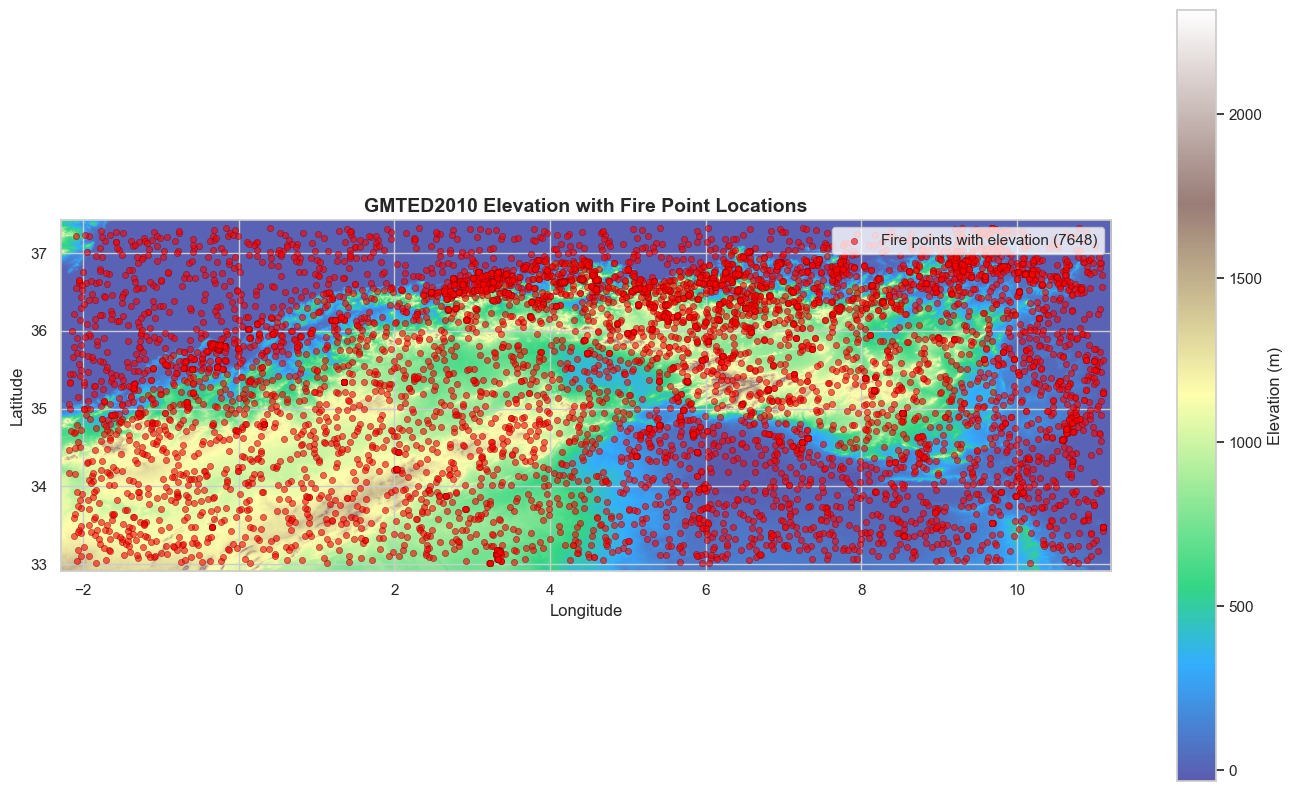

✓ Visualization complete!


In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot clipped elevation raster
band1 = clipped_array[0].astype('float32')
if raster_nodata is not None:
    band1[band1 == raster_nodata] = np.nan

extent = plotting_extent(band1, transform=new_transform)
im = ax.imshow(band1, cmap='terrain', extent=extent, origin='upper', alpha=0.8)

# Overlay fire points
fires_with_elev = fires_df[fires_df['elevation'].notna()]
fires_without_elev = fires_df[fires_df['elevation'].isna()]

ax.scatter(fires_with_elev['longitude'], fires_with_elev['latitude'], 
           c='red', s=20, alpha=0.6, edgecolors='darkred', linewidth=0.5,
           label=f'Fire points with elevation ({len(fires_with_elev)})')

if len(fires_without_elev) > 0:
    ax.scatter(fires_without_elev['longitude'], fires_without_elev['latitude'], 
               c='orange', s=20, alpha=0.6, marker='x',
               label=f'Fire points without elevation ({len(fires_without_elev)})')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('GMTED2010 Elevation with Fire Point Locations', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
fig.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
plt.tight_layout()
plt.show()

print(f"✓ Visualization complete!")

---
## Section 3: Data Preprocessing

### 3.1 Compute Derived Terrain Features

In [22]:
print("="*60)
print("TERRAIN FEATURE COMPUTATION")
print("="*60)

# Get elevation band (replace NoData with NaN for computation)
elevation = clipped_array[0].astype('float32')
if raster_nodata is not None:
    elevation[elevation == raster_nodata] = np.nan

print("\n1. Computing Slope...")
slope = compute_slope(elevation, cell_size=450)
print(f"  ✓ Slope computed (range: {np.nanmin(slope):.2f}° to {np.nanmax(slope):.2f}°)")

print("\n2. Computing Aspect...")
aspect = compute_aspect(elevation)
print(f"  ✓ Aspect computed (range: {np.nanmin(aspect):.2f}° to {np.nanmax(aspect):.2f}°)")

print("\n3. Computing Terrain Roughness...")
roughness = compute_roughness(elevation)
print(f"  ✓ Roughness computed (range: {np.nanmin(roughness):.2f} to {np.nanmax(roughness):.2f})")

print("\n✓ All terrain features computed successfully!")
print("="*60)

TERRAIN FEATURE COMPUTATION

1. Computing Slope...
  ✓ Slope computed (range: 0.00° to 53.09°)

2. Computing Aspect...
  ✓ Aspect computed (range: 0.00° to 359.89°)

3. Computing Terrain Roughness...
  ✓ Roughness computed (range: 0.00 to 504.23)

✓ All terrain features computed successfully!


### 3.2 Extract Terrain Features at Fire Locations

In [23]:
print("="*60)
print("EXTRACTING TERRAIN FEATURES AT FIRE LOCATIONS")
print("="*60)

slope_values = []
aspect_values = []
roughness_values = []

for idx, point in enumerate(fires_gdf.geometry):
    lon, lat = point.x, point.y
    row, col = rowcol(new_transform, lon, lat)
    
    if 0 <= row < slope.shape[0] and 0 <= col < slope.shape[1]:
        slope_values.append(slope[row, col])
        aspect_values.append(aspect[row, col])
        roughness_values.append(roughness[row, col])
    else:
        slope_values.append(np.nan)
        aspect_values.append(np.nan)
        roughness_values.append(np.nan)

# Add to dataframe
fires_df['slope'] = slope_values
fires_df['aspect'] = aspect_values
fires_df['roughness'] = roughness_values

print(f"✓ Terrain features extracted!")
print(f"\nFeature Summary:")
print(f"  Elevation: {fires_df['elevation'].notna().sum()} valid values")
print(f"  Slope: {fires_df['slope'].notna().sum()} valid values")
print(f"  Aspect: {fires_df['aspect'].notna().sum()} valid values")
print(f"  Roughness: {fires_df['roughness'].notna().sum()} valid values")

print("\nSample data:")
print(fires_df[['longitude', 'latitude', 'class', 'elevation', 'slope', 'aspect', 'roughness']].head(10))
print("="*60)

EXTRACTING TERRAIN FEATURES AT FIRE LOCATIONS
✓ Terrain features extracted!

Feature Summary:
  Elevation: 7648 valid values
  Slope: 7648 valid values
  Aspect: 7648 valid values
  Roughness: 7648 valid values

Sample data:
   longitude  latitude  class  elevation      slope      aspect   roughness
0    9.82563  36.81855      1         28   0.063662    0.000000    0.816497
1    3.08190  35.80751      0        813   3.660967   20.323135   18.979521
2    7.24027  34.56991      1        149   0.586914  139.398712    5.333333
3    1.60481  35.55047      0        792   5.848942  167.471191   51.508358
4    6.76514  36.55581      1        666   6.630754   58.284866   46.505676
5   10.90887  33.60776      0          0   0.063662   90.000000    0.471405
6    3.13490  36.60116      1         58   0.063662   90.000000    3.448027
7    3.84587  36.39551      1        587   7.636483  260.459625   42.742123
8    1.63896  36.37794      0        558  11.163505  142.549423  120.768372
9    2.66485  3

### 3.3 Normalize Terrain Features

In [24]:
print("="*60)
print("FEATURE NORMALIZATION")
print("="*60)

# Select terrain features for normalization
terrain_features = ['elevation', 'slope', 'aspect', 'roughness']

# Create a copy with only valid data for normalization
fires_with_terrain = fires_df[fires_df[terrain_features].notna().all(axis=1)].copy()

print(f"\nRecords with complete terrain data: {len(fires_with_terrain)}")
print(f"Records with missing terrain data: {len(fires_df) - len(fires_with_terrain)}")

if len(fires_with_terrain) > 0:
    # Initialize scaler
    scaler = StandardScaler()
    
    # Fit and transform
    fires_with_terrain[terrain_features] = scaler.fit_transform(fires_with_terrain[terrain_features])
    
    print(f"\n✓ Normalized {len(terrain_features)} terrain features using StandardScaler")
    print(f"  Method: (x - mean) / std")
    print(f"  Result: Mean ≈ 0, Std ≈ 1")
    
    print(f"\nNormalized statistics:")
    for feat in terrain_features:
        mean = fires_with_terrain[feat].mean()
        std = fires_with_terrain[feat].std()
        print(f"  {feat}: mean={mean:.6f}, std={std:.6f}")
else:
    print("  ⚠ No records with complete terrain data for normalization")

print("="*60)

FEATURE NORMALIZATION

Records with complete terrain data: 7648
Records with missing terrain data: 0

✓ Normalized 4 terrain features using StandardScaler
  Method: (x - mean) / std
  Result: Mean ≈ 0, Std ≈ 1

Normalized statistics:
  elevation: mean=-0.000000, std=1.000065
  slope: mean=0.000000, std=1.000065
  aspect: mean=0.000000, std=1.000065
  roughness: mean=-0.000000, std=1.000065


---
## Section 4: Exploratory Data Analysis

### 4.1 Descriptive Statistics

In [25]:
print("="*60)
print("TERRAIN FEATURE STATISTICS")
print("="*60)

if len(fires_with_terrain) > 0:
    desc_stats = fires_with_terrain[terrain_features].describe()
    print("\nDescriptive Statistics (Normalized):")
    print(desc_stats)
    
    # Original (non-normalized) statistics
    print("\nOriginal Statistics (Before Normalization):")
    orig_stats = fires_df[fires_df[terrain_features].notna().all(axis=1)][terrain_features].describe()
    print(orig_stats)
else:
    print("\nNo data available for statistics")

print("\n✓ Statistics computed!")
print("="*60)

TERRAIN FEATURE STATISTICS

Descriptive Statistics (Normalized):
          elevation         slope        aspect     roughness
count  7.648000e+03  7.648000e+03  7.648000e+03  7.648000e+03
mean  -1.396594e-08  6.484187e-09  4.987836e-09 -4.987836e-09
std    1.000065e+00  1.000065e+00  1.000065e+00  1.000065e+00
min   -1.047109e+00 -6.395746e-01 -1.761676e+00 -6.737540e-01
25%   -9.101672e-01 -5.872436e-01 -8.481647e-01 -6.040062e-01
50%   -4.261496e-01 -4.509079e-01  2.398221e-02 -4.576630e-01
75%    8.795171e-01  1.210197e-01  7.987476e-01  1.836769e-01
max    3.505017e+00  7.716784e+00  1.889797e+00  7.632295e+00

Original Statistics (Before Normalization):
         elevation        slope       aspect    roughness
count  7648.000000  7648.000000  7648.000000  7648.000000
mean    413.490717     3.207987   173.561981    28.070877
std     423.566077     5.016141    98.527367    41.666111
min     -30.000000     0.000000     0.000000     0.000000
25%      28.000000     0.262483    90.0000

### 4.2 Terrain Feature Distributions

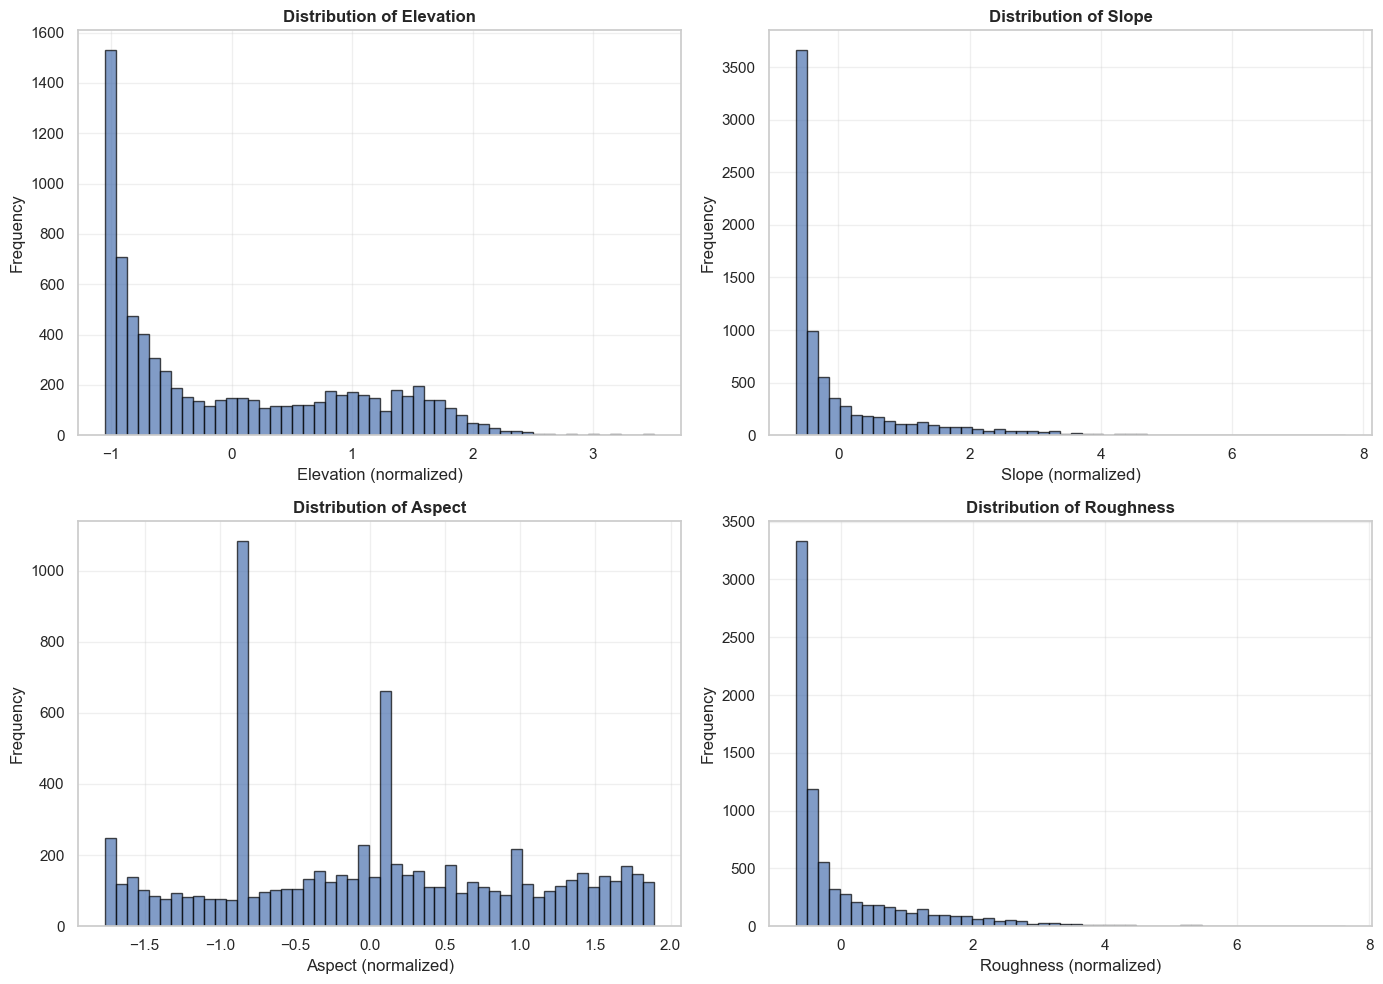

✓ Distribution plots complete!


In [26]:
if len(fires_with_terrain) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, feat in enumerate(terrain_features):
        ax = axes[idx]
        fires_with_terrain[feat].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'Distribution of {feat.capitalize()}', fontweight='bold')
        ax.set_xlabel(f'{feat.capitalize()} (normalized)')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Distribution plots complete!")
else:
    print("No data available for plotting")

### 4.3 Bivariate Terrain Relationships

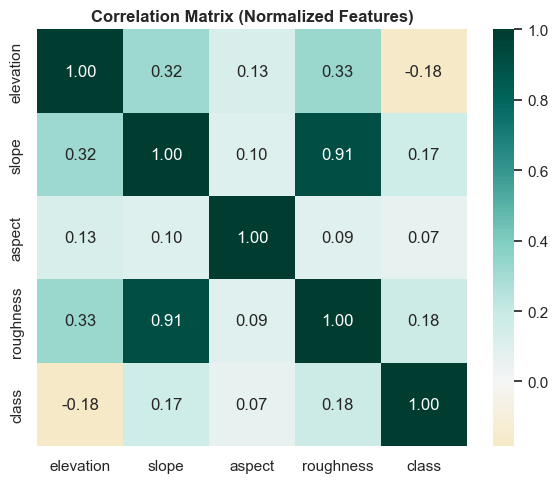

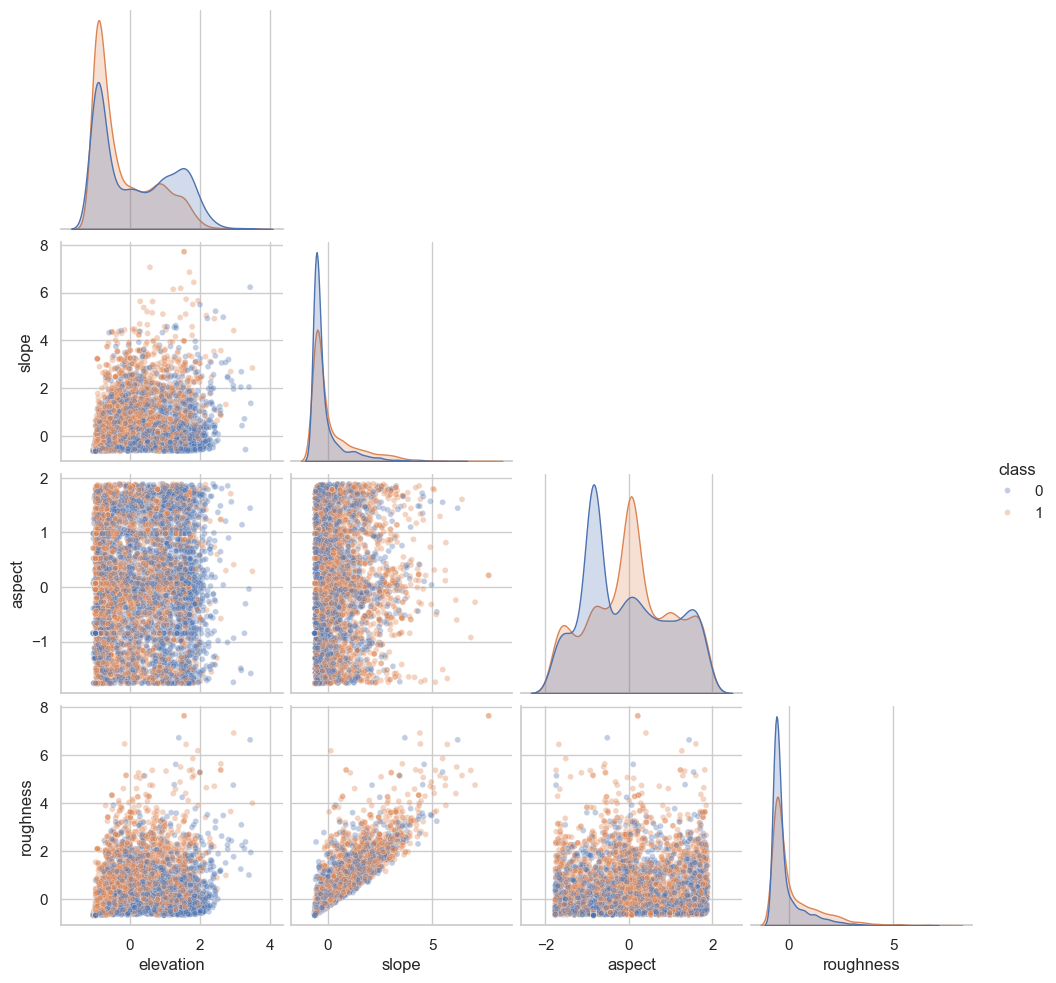

In [27]:
if len(fires_with_terrain) > 0:
    # Correlation matrix to assess linear relationships
    corr = fires_with_terrain[terrain_features + ['class']].corr()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap='BrBG', center=0, ax=ax, fmt='.2f')
    ax.set_title('Correlation Matrix (Normalized Features)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Pairwise scatter distribution for terrain features vs class
    sns.pairplot(
        fires_with_terrain[['class'] + terrain_features],
        hue='class',
        diag_kind='kde',
        corner=True,
        plot_kws={'alpha': 0.35, 's': 18}
    )
    plt.show()
else:
    print('No data available for bivariate analysis')

### 4.4 Fire vs Terrain Relationship

FIRE VS TERRAIN ANALYSIS

Fire points: 3824
No-fire points: 3824

Mean Terrain Features by Fire Class:
------------------------------------------------------------
elevation   : Fire= -0.183, No-Fire=  0.183
slope       : Fire=  0.170, No-Fire= -0.170
aspect      : Fire=  0.067, No-Fire= -0.067
roughness   : Fire=  0.179, No-Fire= -0.179


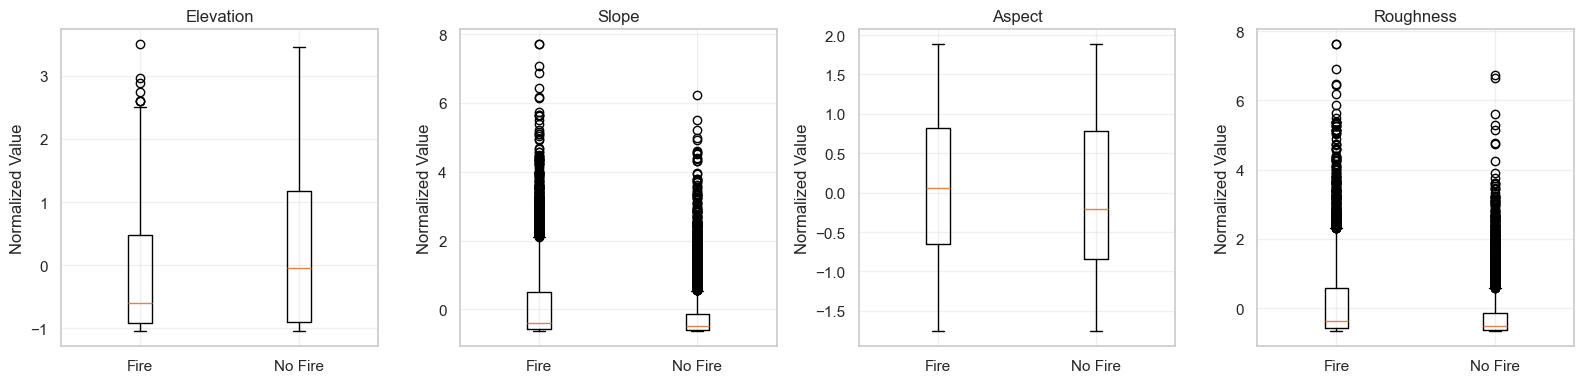


✓ Fire vs terrain analysis complete!


In [28]:
if len(fires_with_terrain) > 0:
    print("="*60)
    print("FIRE VS TERRAIN ANALYSIS")
    print("="*60)
    
    # Separate fire and no-fire
    fire_data = fires_with_terrain[fires_with_terrain['class'] == 1]
    no_fire_data = fires_with_terrain[fires_with_terrain['class'] == 0]
    
    print(f"\nFire points: {len(fire_data)}")
    print(f"No-fire points: {len(no_fire_data)}")
    
    # Compare mean values
    print("\nMean Terrain Features by Fire Class:")
    print("-" * 60)
    for feat in terrain_features:
        fire_mean = fire_data[feat].mean()
        no_fire_mean = no_fire_data[feat].mean()
        print(f"{feat:12s}: Fire={fire_mean:7.3f}, No-Fire={no_fire_mean:7.3f}")
    
    # Boxplot comparison
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for idx, feat in enumerate(terrain_features):
        ax = axes[idx]
        data_to_plot = [fire_data[feat].dropna(), no_fire_data[feat].dropna()]
        ax.boxplot(data_to_plot, labels=['Fire', 'No Fire'])
        ax.set_title(f'{feat.capitalize()}')
        ax.set_ylabel('Normalized Value')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Fire vs terrain analysis complete!")
    print("="*60)
else:
    print("No data available for analysis")

---
## Section 5: Save Results

Save all processed data and generate summary reports.

In [29]:
print("="*60)
print("SAVING RESULTS")
print("="*60)

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save fires with elevation features (normalized)
output_path_fires = results_dir / 'fires_with_elevation_features.csv'
fires_with_terrain.to_csv(output_path_fires, index=False)

print(f"\n✓ [PRIMARY OUTPUT] Fires with elevation features saved:")
print(f"  📄 {output_path_fires}")
print(f"  Shape: {fires_with_terrain.shape}")
print(f"  Columns: {list(fires_with_terrain.columns)}")

# Save clipped elevation raster
output_path_raster = results_dir / 'elevation_raster_fires_clipped.tif'
tif_profile = clipped_profile.copy()
tif_profile.update(driver='GTiff')
with rio.open(output_path_raster, 'w', **tif_profile) as dst:
    dst.write(clipped_array)
print(f"\n✓ Clipped elevation raster saved:")
print(f"  📄 {output_path_raster}")

# Generate summary report
summary_path = results_dir / 'elevation_processing_summary.txt'
with open(summary_path, 'w') as f:
    f.write("ELEVATION DATA PROCESSING SUMMARY\n")
    f.write("="*60 + "\n\n")
    
    f.write("Input Data:\n")
    f.write(f"  - GMTED2010 Elevation Raster\n")
    f.write(f"  - Resolution: 15 arc-seconds (~450m)\n")
    f.write(f"  - Original size: {raster_data.shape[1]} x {raster_data.shape[2]} pixels\n")
    f.write(f"  - Fire points: {len(fires_df):,}\n\n")
    
    f.write("Spatial Operations:\n")
    f.write(f"  - Clipped size: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels\n")
    f.write(f"  - Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%\n\n")
    
    f.write("Features Computed:\n")
    f.write(f"  - Elevation (m)\n")
    f.write(f"  - Slope (degrees)\n")
    f.write(f"  - Aspect (degrees, 0-360)\n")
    f.write(f"  - Terrain Roughness Index\n\n")
    
    f.write("Final Output:\n")
    f.write(f"  - File: {output_path_fires.name}\n")
    f.write(f"  - Records with complete terrain data: {len(fires_with_terrain):,}\n")
    f.write(f"  - Normalized features: 4 (elevation, slope, aspect, roughness)\n")
    f.write(f"  - Normalization method: StandardScaler (z-score)\n")

print(f"\n✓ Summary report saved:")
print(f"  📄 {summary_path}")

print("\n" + "="*60)
print("✓ ALL PROCESSING COMPLETE!")
print("="*60)
print(f"\n🎯 PRIMARY OUTPUT:")
print(f"  → {output_path_fires.name}")
print(f"  → {fires_with_terrain.shape[0]} records × {fires_with_terrain.shape[1]} columns")
print(f"  → longitude, latitude, class + 4 normalized terrain features")
print(f"\n📁 Additional files:")
print(f"  → {output_path_raster.name}")
print(f"  → {summary_path.name}")
print("="*60)

SAVING RESULTS

✓ [PRIMARY OUTPUT] Fires with elevation features saved:
  📄 ..\results\fires_with_elevation_features.csv
  Shape: (7648, 7)
  Columns: ['longitude', 'latitude', 'class', 'elevation', 'slope', 'aspect', 'roughness']

✓ Clipped elevation raster saved:
  📄 ..\results\elevation_raster_fires_clipped.tif

✓ Summary report saved:
  📄 ..\results\elevation_processing_summary.txt

✓ ALL PROCESSING COMPLETE!

🎯 PRIMARY OUTPUT:
  → fires_with_elevation_features.csv
  → 7648 records × 7 columns
  → longitude, latitude, class + 4 normalized terrain features

📁 Additional files:
  → elevation_raster_fires_clipped.tif
  → elevation_processing_summary.txt
